<a href="https://colab.research.google.com/github/jameshphan-png/Coding-Exercise---ML-Basics/blob/dev/Module_3_Coding_Exercise_Extra_Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

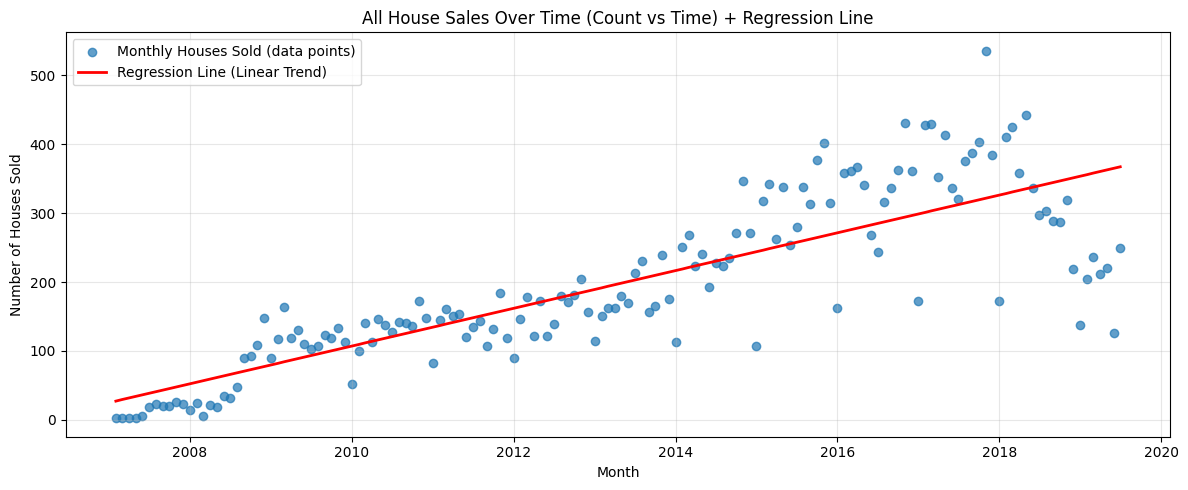

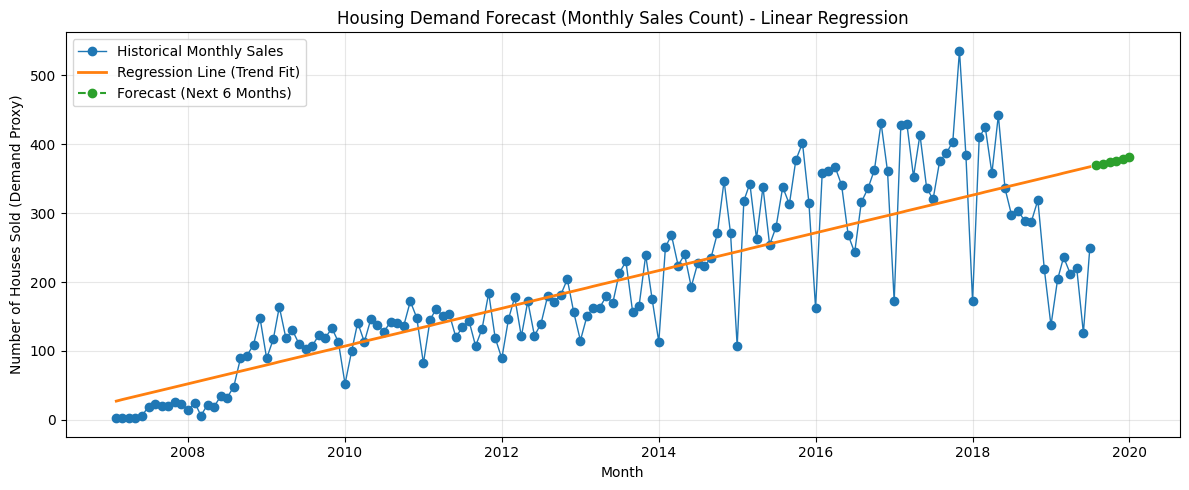


6-Month Demand Forecast (Demand = Monthly Houses Sold):
     month  predicted_sales
2019-08-01              370
2019-09-01              372
2019-10-01              374
2019-11-01              377
2019-12-01              379
2020-01-01              381

Why might predicted monthly sales be > 350 as the forecast?
- Dataset months used: 150
- Monthly sales range: min=2, max=536
- Monthly sales average: 197.2
- Last observed month: 2019-07-01 with sales=250
- This model fits ONE straight trend line across the entire history.
  If the long-term slope is upward, extrapolating 6 months ahead can land above 350,
  even if some recent months were lower (because older high-volume periods still influence the fit).

Assumptions / Challenges / Improvements
- Assumption: 'Demand' is represented by the number of houses sold per month (transaction count).
- Assumption: A linear trend over time is a reasonable first baseline (no seasonality, no shocks).
- Challenge: Housing demand is seasonal; a strai

In [1]:
# ------------------------------------------------------------
# IMPORTANT (READ ME BEFORE STARTING)
#
# Ensure you have downloaded "raw_sales.csv" as the excel file obtained from Github.
# USE THE EXCEL FILE AND UPLOAD INTO THE RUNTIME IN COLAB THROUGH THE 'Files' TAB, DRAG & DROP TO THE TAB.
# ------------------------------------------------------------

# ======================================================
# Dataset Source:
# Kaggle - "House Property Sales Time Series" Dataset
# https://www.kaggle.com/datasets/htagholdings/property-sales
# ======================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load + Clean
# -----------------------------
df = pd.read_csv('raw_sales.csv')

df['datesold'] = pd.to_datetime(df['datesold'], errors='coerce')
df = df.dropna(subset=['datesold', 'price'])
df = df[df['price'] > 0]

# Convert each sale date to the first day of its month (e.g., 2019-07-15 -> 2019-07-01)
df['month'] = df['datesold'].dt.to_period('M').dt.to_timestamp()

# -----------------------------
# 2) Build monthly series
#    Demand proxy = number of houses sold per month
# -----------------------------
monthly = (
    df.groupby('month')
      .size()
      .reset_index(name='sales')
      .sort_values('month')
)

# Create a numeric time index t = 0..N-1
# This is what lets LinearRegression model a "trend over time"
monthly['t'] = np.arange(len(monthly))

X = monthly[['t']]
y = monthly['sales']

# =========================================================
# MODEL A: "All house sales (count) vs time" + regression line
# =========================================================
sales_trend_model = LinearRegression()
sales_trend_model.fit(X, y)

# Regression line = fitted values on historical months
monthly['fitted_sales'] = sales_trend_model.predict(X)

plt.figure(figsize=(12, 5))
plt.scatter(monthly['month'], monthly['sales'], alpha=0.7, label='Monthly Houses Sold (data points)')
plt.plot(
    monthly['month'],
    monthly['fitted_sales'],
    color='red',           # requested: red regression line
    linewidth=2,
    label='Regression Line (Linear Trend)'
)

plt.title('All House Sales Over Time (Count vs Time) + Regression Line')
plt.xlabel('Month')
plt.ylabel('Number of Houses Sold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# MODEL B: 6-month forecast (separate model instance)
# =========================================================
# NOTE: It's still LinearRegression, but a separate instance as requested.
forecast_model = LinearRegression()
forecast_model.fit(X, y)

# -----------------------------
# How forecasting is calculated:
# -----------------------------
# The model learns:  sales ≈ intercept + slope * t
# To forecast 6 months ahead, we extend t by 6 steps beyond the last observed month.
#
# Example:
#   if last observed t = 149,
#   future t values are 150, 151, 152, 153, 154, 155
# These represent the next 6 months in sequence.
last_t = int(monthly['t'].iloc[-1])
future_t = np.arange(last_t + 1, last_t + 7)  # next 6 time steps

# Build the matching future month labels (for plotting/printing)
last_month = monthly['month'].iloc[-1]
future_months = pd.date_range(last_month + pd.offsets.MonthBegin(1), periods=6, freq='MS')

future_df = pd.DataFrame({'month': future_months, 't': future_t})

# Apply the model to future months:
# predictions are just the regression line evaluated at future t values.
predictions = forecast_model.predict(future_df[['t']])

# Demand can't be negative; clip for safety
predictions = np.clip(predictions, 0, None)

# Plot historical + regression line + forecast
plt.figure(figsize=(12, 5))
plt.plot(monthly['month'], monthly['sales'], marker='o', linewidth=1, label='Historical Monthly Sales')
plt.plot(monthly['month'], monthly['fitted_sales'], linewidth=2, label='Regression Line (Trend Fit)')
plt.plot(future_df['month'], predictions, linestyle='--', marker='o', label='Forecast (Next 6 Months)')

plt.title('Housing Demand Forecast (Monthly Sales Count) - Linear Regression')
plt.xlabel('Month')
plt.ylabel('Number of Houses Sold (Demand Proxy)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Printed output + explanation
# -----------------------------
forecast_out = future_df.copy()
forecast_out['predicted_sales'] = predictions.round(0).astype(int)

print("\n6-Month Demand Forecast (Demand = Monthly Houses Sold):")
print(forecast_out[['month', 'predicted_sales']].to_string(index=False))

# Helpful diagnostics to explain "why is it over 350?"
print("\nWhy might predicted monthly sales be > 350 as the forecast?")
print(f"- Dataset months used: {len(monthly)}")
print(f"- Monthly sales range: min={int(monthly['sales'].min())}, max={int(monthly['sales'].max())}")
print(f"- Monthly sales average: {monthly['sales'].mean():.1f}")
print(f"- Last observed month: {monthly['month'].iloc[-1].date()} with sales={int(monthly['sales'].iloc[-1])}")
print("- This model fits ONE straight trend line across the entire history.")
print("  If the long-term slope is upward, extrapolating 6 months ahead can land above 350,")
print("  even if some recent months were lower (because older high-volume periods still influence the fit).")

print("\nAssumptions / Challenges / Improvements")
print("- Assumption: 'Demand' is represented by the number of houses sold per month (transaction count).")
print("- Assumption: A linear trend over time is a reasonable first baseline (no seasonality, no shocks).")
print("- Challenge: Housing demand is seasonal; a straight line cannot model recurring yearly patterns.")
print("- Challenge: A single global trend can be distorted by regime shifts (policy, interest rates, economic events).")
print("- Improvement: Add seasonality features (month-of-year one-hot or sin/cos).")
print("- Improvement: Add lag/rolling features (previous month, 3-month rolling mean).")
print("- Improvement: Time-based validation (hold out last 6–12 months) to measure MAE/RMSE and check realism.")
